<a href="https://colab.research.google.com/github/jccrews256/ST-554-HW-5/blob/main/Homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ST 554 Homework 5

*By: Cass Crews*

## Part I: Concepts



#### Question I

*Prompt: We discussed the “Five V's of Big Data”. Give an example of a place where you've encountered big
data or a topic you are interested in where big data would arise. Specifically address the five V's for
the example and whether/how they apply to your example.*

I am currently leading a team that is building a relational database of socioeconomic data, which is used to build custom data dashboards and decision-making tools for communities that can't afford products from for-profit data providers. This database generally connects to public and proprietary datasets through APIs, with API calls rununing at the end of each day to ensure the data are up to date.

The five V's of big data map to this project in the following ways:

* Volume: The data are stored in the cloud for ease of access from the web-based dashboards and tools. At roughly four gigabytes of data, it would not be impossible to analyze and visualize the data locally on a standard work laptop. However, the cloud-based storage and analysis of this dataset is more manageable even if the utilization of the cloud is largely for online broadcasting purposes.
* Variety: The data come from 28 different sources and cover several geographic levels. Thus, the data exhibit substantial variety, which results in thousands of lines of code being necessary to automate the process of cleaning and relating the data.
    * For anyone interested, most geographies we focus on are counties or collections of counties. Thus, tables are related by multiple heirarchically structured keys that connect individual counties to broader regions.
* Velocity: By batch-updating the raw data daily, the "velocity" of the database is controlled in one sense. However, in reality, velocity is determined by the release schedules of the sources. Some sources, such as the Census Bureau's American Community Survey, have fixed annual release schedule, while other sources have less predictable releases. The uncertainty makes maintenance a bit tricky, as an unpredictable source data update may also involve an unpredictable update to the structure of the corresponding raw data. We build fail-safes into the data cleaning scripts, but we can't foresee all structure changes!
* Veracity/Variability: This V comes in two major ways.
    * First, effectively every value we visualize, report, or analyze for communities is an estimate of some community characteristic extracted from surveys or government administrative records. My team and I view it as our job to quantify, or at least understand, this uncertainty for each potential data source to identify the least variable (and least biased) measure of a given socioeconomic characteristic; as an example, we prefer employment data built from administrative records rather than survey-based data.
    * Second, uncertainty around new and revised observations makes related machine learning challenging. As an example, we have built clustering models to identify structural peers for communities; these match communities in terms of "economic inputs" such as the industry mix of employment. However, even these "inputs" can be impacted by major economic downturns. This means that any assymetry in an economic downturn's impacts across the United States could have a massive impact on model-identified peers. I'm still evaluating options for handling this uncertainty and its impact on model stability.
* Value: This is the north star of the project. Our goal is to majorly reduce the barriers to data-backed decision making, so we are explicitly focused on extracting value/signals from socioeconomic data to generate better outcomes for communities' residents.

#### Question 2

*Prompt: Read about the database we'll use below (part IV). Give an example for each letter in the CRUD acronym in the context of this database.*

STILL NEED TO ANSWER



#### Question 3

*Prompt: What is the purpose of the HAVING clause when writing SQL code? (Recall the sqlitetutorial.net tutorial on the SELECT statement.)*

The purpose of the HAVING clause is to subset the groups created by a GROUP BY clause. That is, once the GROUP BY clause creates aggregate records summarizing groups of observations, the HAVING clause filters the aggregate records by some logical specified by the query writer in the clause.


## Part II: Simulation of a Sampling Distribution

#### Question 4

In this part, we will use simulation to study the sampling distribution of the sample slope in a simple linear regression (SLR) model. More specifically, we will assume the following model for the relationship between a response, $Y$, and a predictor, $x$,

$$Y_i = \beta_0 + \beta_1 x_i + E_i.$$

$Y_i$ and $x_i$ are the $i$th observations of the response and predictor, respectively, with $i=1,...,n$. We will assume $E_i \overset{iid}{\sim}N(0,1)$. Our simulation will explore the sampling distribution of $\hat{\beta}_1$, the ordinary least square estimate for $\beta_1$.

To study the slope estimate via simulation, we will need to repeatedly draw response and predictor values from the same distributions and fit an SLR model to the simulated data.

The code chunk provided in the instructions demonstrates the process of simulating a single dataset. The predictor values are "generated" by assuming we three observations of $x$ at each integer from 0 to 10; this implies $n$=33. The response values are generated by assuming $\beta_0$=7 and $\beta_1$=1.5. The code chunk is run below. It produces a plot of the single simulated dataset.


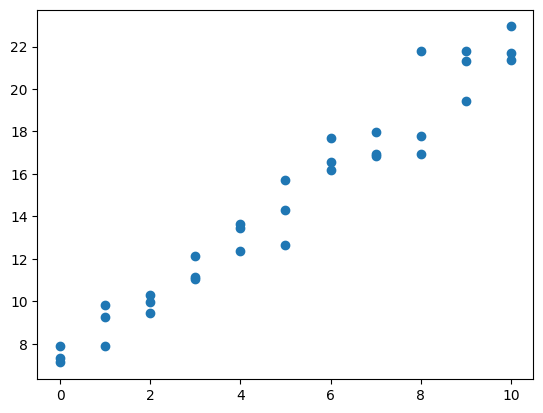

In [1]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5
# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33
#create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n)
#visualize the data
plt.scatter(x = x, y = y)
plt.show()


Note that the relationship between our predictor and response is relatively strong because of the scale of the true slope value in comparison to the variability of $Y$ about its conditional mean ($\sigma^2=1$).

Now that we are able to simulate a dataset, we need to be able to extract the slope estimate relating $Y$ and $x$. To do so, we will use the `linear_model` submodule from `sklearn`.

In [2]:
# Read in linear_model submodule
from sklearn import linear_model

# Create a reg object
reg = linear_model.LinearRegression()

# Fit model between Y and x and print coefficients
reg.fit(x.reshape(-1,1), y)
print(reg.intercept_, reg.coef_)

7.259043801350283 [1.47450564]


Because of the strength of the simulated relationship between the response and predictor, we were able to fit the model relatively well; both coefficient estimates are fairly close to the true values.

We now want to repeat this process of simulating a dataset and fitting an SLR model 5,000 times to obtain a simulated sampling distribution for $\hat{\beta}_1$. To do so, we will construct a `for` loop that will repeat the above process. The 5,000 slope values will be capturing in a `numpy` array, `slopes`.

In [3]:
# Creating an array to capture slope estimates
slopes = np.zeros(5000)

for i in range(5000):
    # Get three 'values' of x at each integer from 0 to 10.
    x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
    n = 33
    # Create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)

    # Fitting model to simulated data
    reg.fit(x.reshape(-1,1), y)

    # Capturing estimated slope
    slopes[i] = reg.coef_[0]


Let's print the first and final few slopes to ensure the code worked as intended.


In [4]:
print("First five estimates:", slopes[:5])
print("Final five estimates:", slopes[-5:])

First five estimates: [1.45280552 1.53315358 1.47203179 1.44166898 1.48156797]
Final five estimates: [1.46147432 1.46119866 1.5023274  1.50048984 1.54545847]


It seems our `for` loop worked, so we are ready to explore the simulated sampling distribution. We will begin with a visual exploration: a histogram of the 5,000 slope estimates.

Text(0.5, 1.0, 'Simulated Sampling Distribution of Slope Estimate')

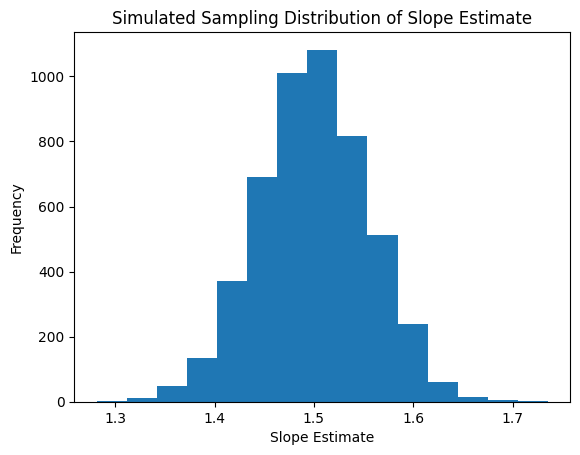

In [5]:
# Creating a basic histogram of slope coefficients with 15 bins
plt.hist(slopes, bins = 15)
plt.xlabel("Slope Estimate")
plt.ylabel("Frequency")
plt.title("Simulated Sampling Distribution of Slope Estimate")

Statistical theory tells us the sampling distribution of the slope estimate is normally distributed when our errors are normally distributed, so it is not surprising to see a bell curve for our 5,000 estimates.

We can use this simulated sampling distribution to estimate the probability of obtaining slope estimates at least as extreme as a certain value. For example, we can estimate the probability of obtaining a slope estimate above 1.65 given that the true slope is 1.5. Let's try that now.

In [6]:
# Estimating probability of a slope above 1.65
prob = np.sum(slopes > 1.65)/slopes.shape[0]

print("Probability of obtaining a slope estimate above 1.65:", prob)

Probability of obtaining a slope estimate above 1.65: 0.0038


Given that the true slope is 1.5, the estimated probability of obtaining a slope estimate greater than 1.65 is 0.0038. Thus, an estimate this high is extreemely unlikely. Such information can be very useful when conducting hypothesis testing. For example, if our null hypothesis is that the true slope is 1.5 and our other model assumptions are reasonable, obtaining a sample slope above 1.65 would lead us to question whether our null hypothesis is valid. More directly, if our alternative hypothesis is that the true slope is actually higher than 1.5, we would reject the null hypothesis for most standard significance levels (e.g., a 0.01 or 0.05 significance level) due to the estimated probability being so low.

## Part III: Big Data Examples and Rare Events

For Part III, we will review three different paper highlighting opportunities and challenges in big data modeling.

#### Question 5

For this question, we are reviewing the paper [Biases in machine learning models and big data analytics: The international criminal and humanitarian law implications](https://international-review.icrc.org/articles/biases-machine-learning-big-data-analytics-ihl-implications-913). In particular, we are identifying an example of bias negatively impacting a machine learning model and discussing ways to overcome this bias.

The example we will focus on in this notebook highlights an example of implicit bias:

> "In 2018, for example, Amazon found that algorithms used to screen résumés to identify candidates were trained on data containing implicit biases against female applicants, resulting in the algorithm penalizing résumés that included the word 'women,' as in 'women's chess club captain.'"

This is an example of implicit biases because hiring managers' implicit biases against women candidates were baked into the models trained on their hiring decisions. The key to overcoming this issue is often to identify it before training the model and stratify the training set accordingly. That is, if the data scientist knows there are implicit biases against women candidates, they could construct a training set with equal numbers of women who were hired, women who were not hired, men who were hired, and men who were not hired. This "equalization" of probabilities of being in each group for the training set will naturally counter the implicit biases in managers that result in more men and fewer women being hired. Of course, this solution may not fully resolve the issue on it's own, but it is a good first step.

#### Question 6

For this question, we will discuss the use of big data in creating a three-dimensional characterization of Earth's oceans, as described in [Big data in Earth Science: Emerging Practice and Promise](https://www.science.org/doi/10.1126/science.adh9607). The paper notes that combinations of underwater vehicles and buoy-based measurement tools have been used to create a 3-D model of the oceans. In effect, overlapping arrays of measurement devices have been deployed across the world, mapping and measuring the oceans in a variety ways across time. How big are these data? In some ways, a single temporal instance is the size of the ocean itself.

When I consider complexities related to these data, I fixate on one concern: that each measurement tool likely has its own biases: A device attached to a buoy may consistently overestimate depth in the deepest parts of the ocean (where we have little ground truth data) while also suffering from temperature reading drift. The computer vision model used to map the ocean floor via videos recorded by an underwater vehicle could generate surfaces that are much too smooth. I suspect these biases proliferate as the models processing data from a new type of sensor may be trained on biased data generated before it. Overall, the biases of individual measurement tools create a mosaic of oceanic measurements with their own location- and tool-specific biases.

One final thought: for any sections of the ocean so deep that they can only be effectively mapped by unmanned underwater vehicles, observations likely suffer from major time gaps between consecutive measurements, meaning that a key characteristic of the ocean floor may change in these areas long before a new observation informs us of this change. I wonder how effectively models using buoy-based data collection can predict when such a change occurs in the deep depths of our oceans!

#### Question 7

For this question, we will discuss the topic of rare events. This [article](https://allendowney.substack.com/p/superbolts) highlights one important rare event: the superbolt, or extraordinarily powerful lightning strike.

In general, extreme weather events offer salient examples of the importance of accurately modeling rare events: if we underestimate the likelihood of these extreme events, we may develop roads and buildings that cannot withstand an event that is much more common than we may think. Of course, the dynamic component of these distributions makes things even more complicated. For example, homes and commercial buildings across the Deep South were designed under the assumption that major tornadoes are very unlikely. However, weather patterns have substantially shifted over the past few decades, creating a region that is now highly prone to major tornadoes. I saw the impact of the underestimation of the major tornado rate first hand when, on April 27, 2011, [62 tornadoes touched down](https://www.weather.gov/bmx/event_04272011) in my home state of Alabama; three of these tornadoes were among the strongest tornadoes ever recorded.